# Testing for Control States

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("mode.copy_on_write", True)

In [2]:
opioids_prescriptions = pd.read_csv("data/opioids_clean.csv")
opioids_prescriptions = opioids_prescriptions.copy()
opioids_prescriptions = opioids_prescriptions.drop(columns=["Unnamed: 0"])

opioids_deaths = pd.read_csv("data/opioids_deaths.csv")
opioids_deaths = opioids_deaths.copy()
opioids_deaths = opioids_deaths.drop(columns=["Unnamed: 0"])

In [3]:
# exploration
florida_pre_prescription = opioids_prescriptions[opioids_prescriptions["state"] == "FLORIDA"]
florida_pre_prescription = florida_pre_prescription[florida_pre_prescription["year"] < 2010]

florida_pre_deaths = opioids_deaths[opioids_deaths["state"] == "FLORIDA"]
florida_pre_deaths = florida_pre_deaths[florida_pre_deaths["year"] < 2010]

florida_prescription_pre = florida_pre_prescription.groupby("year")["mme_per_1000"].mean()
florida_overdose_pre = florida_pre_deaths.groupby("year")["overdose_per_100k"].mean()

In [4]:
"""
identify which states are similar to florida pre policy (2010)
"""

TOP_N = 10

threshold1 = 0.10  # 10% of florida's _____-
threshold2 = 0.15
threshold3 = 0.30

pre_2010 = opioids_prescriptions[opioids_prescriptions["year"] < 2010]
states = pre_2010["state"].unique()

# similar avg pop
avg_pop_pre_2010 = pre_2010.groupby("state")["population"].mean()

florida_avg_pop = avg_pop_pre_2010["FLORIDA"]

similar_pop = avg_pop_pre_2010[
    np.abs(avg_pop_pre_2010 - florida_avg_pop) < threshold3 * florida_avg_pop
]

# how florida's values change over years
fl_overdose_change = florida_overdose_pre.diff()
print(fl_overdose_change)
fl_overdose_change = fl_overdose_change.dropna()

fl_prescription_change = florida_prescription_pre.diff()
print(fl_prescription_change)
fl_prescription_change = fl_prescription_change.dropna()

overdose_trend = dict()
prescription_trend = dict()

for state in states:
    if state == "FLORIDA":
        continue

    data = pre_2010[pre_2010["state"] == state]
    data_overdose = data.groupby("year")["overdose_per_100k"].mean()
    data_prescription = data.groupby("year")["mme_per_1000"].mean()

    # compute that state's slope differences
    state_overdose_change = data_overdose.diff().dropna()
    state_prescription_change = data_prescription.diff().dropna()

    overdose_trend[state] = np.sum(np.abs(state_overdose_change - fl_overdose_change))
    prescription_trend[state] = np.sum(
        np.abs(state_prescription_change - fl_prescription_change)
    )

# sort the dicts
sorted_overdose_trend = sorted(overdose_trend.items(), key=lambda x: x[1])
sorted_prescription_trend = sorted(prescription_trend.items(), key=lambda x: x[1])

topN_overdose_states = []
topN_prescription_states = []

for i in range(TOP_N):
    # get top n states that have slopes similar to florida
    state_overdose, _ = sorted_overdose_trend[i]
    state_prescription, _ = sorted_prescription_trend[i]

    topN_overdose_states.append(state_overdose)
    topN_prescription_states.append(state_prescription)

print(f"top {TOP_N} states with similar overdose trends: \n{topN_overdose_states}\n")
print(
    f"top {TOP_N} states with similar prescription shipment trends: \n{topN_prescription_states}"
)

# intersection
set(similar_pop.index) & set(topN_overdose_states) & set(topN_prescription_states)

year
2006         NaN
2007    1.266914
2008    0.937930
2009    1.208656
Name: overdose_per_100k, dtype: float64
year
2006              NaN
2007     90017.054217
2008     64832.900487
2009    122020.116557
Name: mme_per_1000, dtype: float64
top 10 states with similar overdose trends: 
[nan, 'NORTH DAKOTA', 'SOUTH DAKOTA', 'WYOMING', 'MARYLAND', 'SOUTH CAROLINA', 'PENNSYLVANIA', 'IOWA', 'UTAH', 'NEBRASKA']

top 10 states with similar prescription shipment trends: 
[nan, 'NEW YORK', 'NEVADA', 'PENNSYLVANIA', 'CALIFORNIA', 'NEW JERSEY', 'VIRGINIA', 'RHODE ISLAND', 'MISSISSIPPI', 'MARYLAND']


{'MARYLAND'}

## Plots

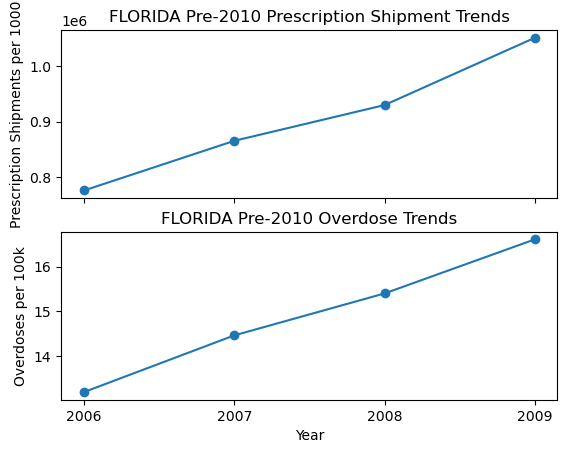

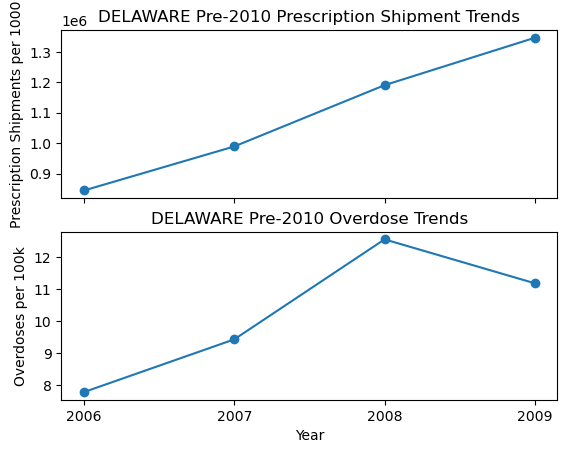

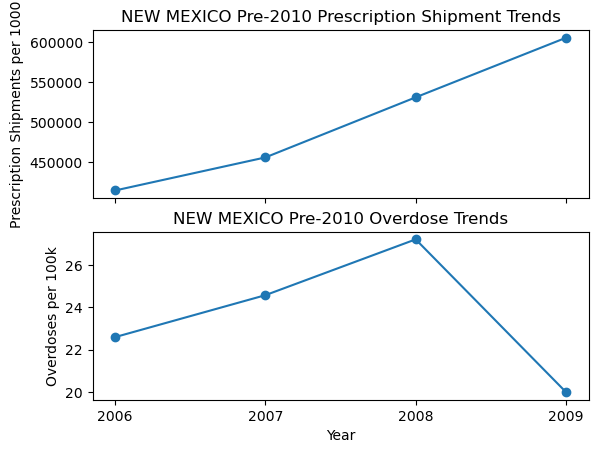

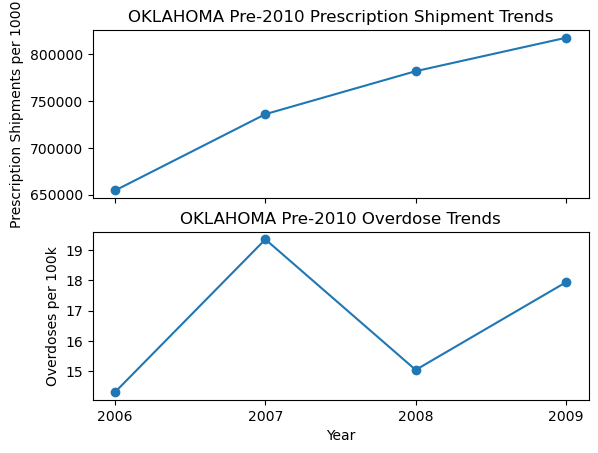

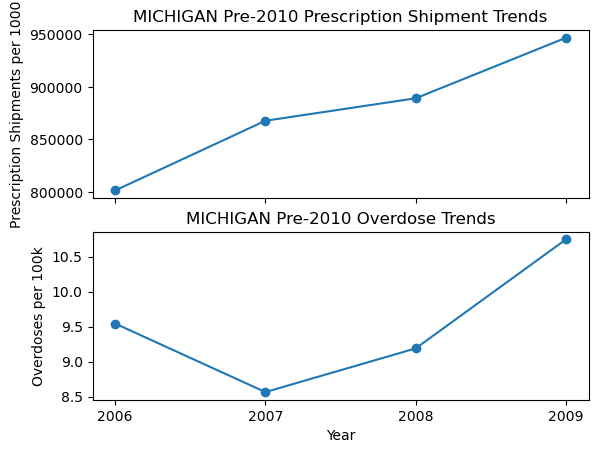

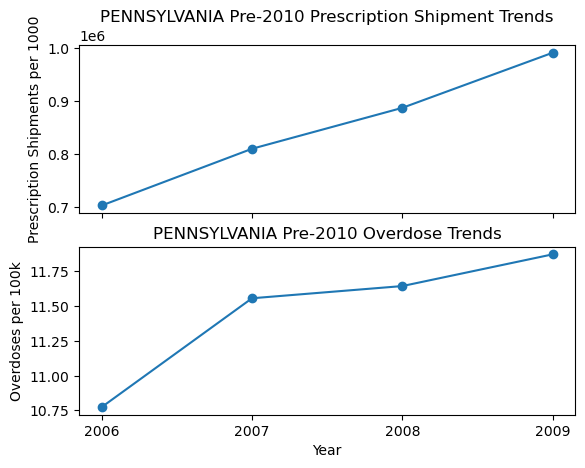

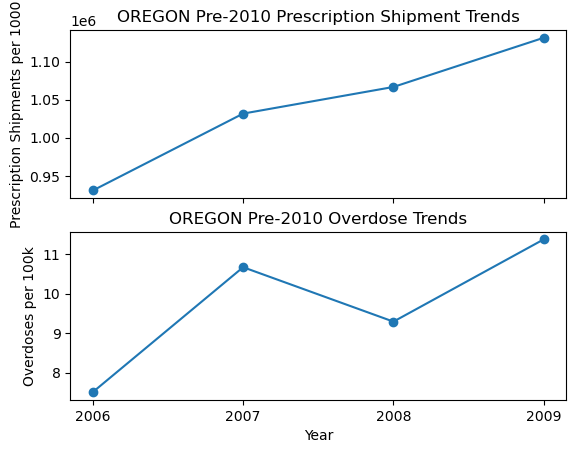

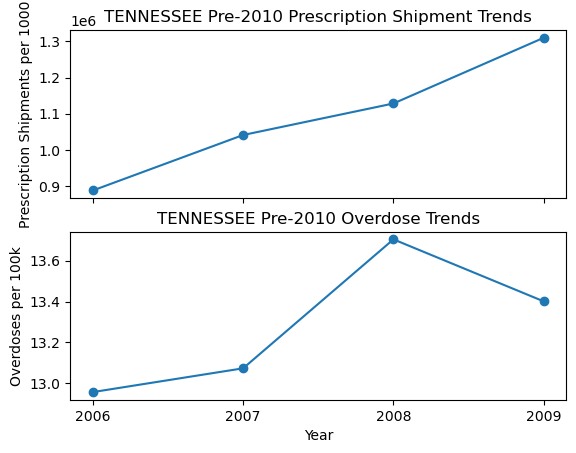

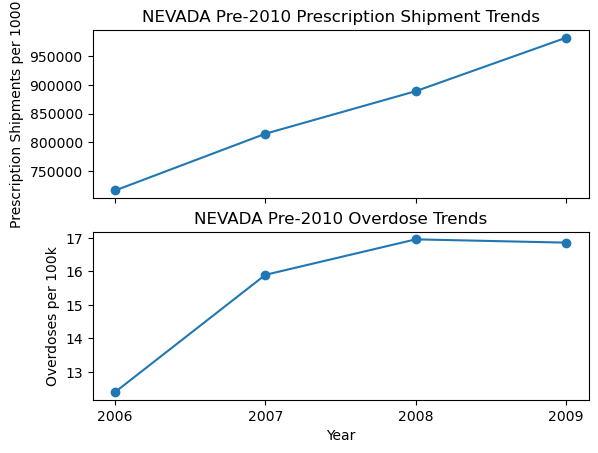

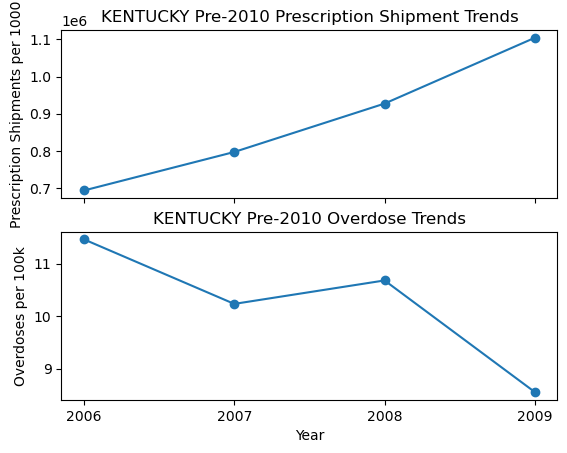

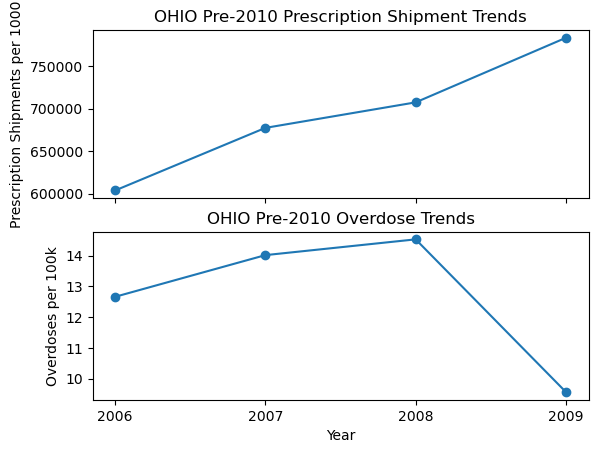

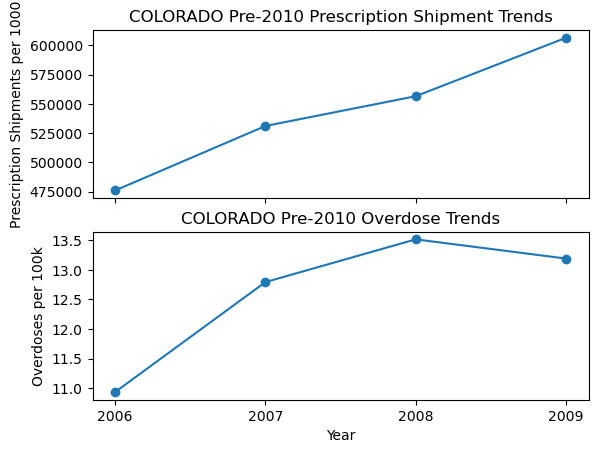

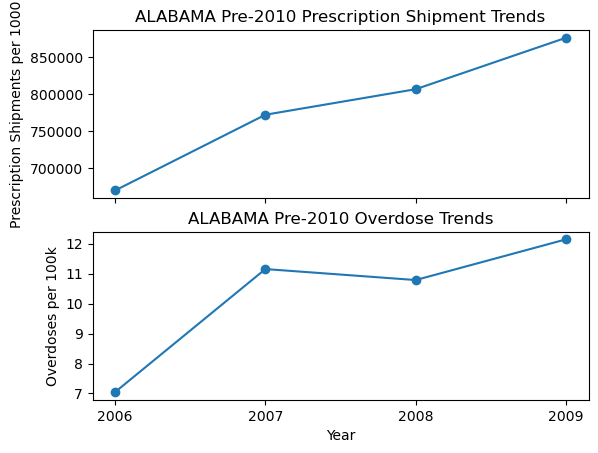

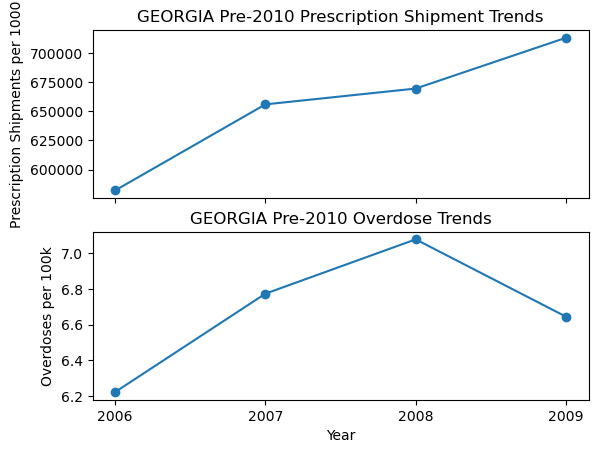

In [7]:
similar_states = [
    # list from top 10 states with similar prescription shipment trends + florida for the loop
    "FLORIDA",
    "DELAWARE",
    "NEW MEXICO",
    "OKLAHOMA",
    "MICHIGAN",
    "PENNSYLVANIA",
    "OREGON",
    "TENNESSEE",
    "NEVADA",
    "KENTUCKY",
    "OHIO",
    "COLORADO",
    "ALABAMA",
    "GEORGIA"
]


for state in similar_states:
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

    data_prescription = opioids_prescriptions[opioids_prescriptions["year"] < 2010]
    data_prescription = data_prescription[data_prescription["state"] == state]
    data_deaths = opioids_deaths[opioids_deaths["year"] < 2010]
    data_deaths = data_deaths[data_deaths["state"] == state]

    m1 = data_deaths.groupby("year")["overdose_per_100k"].mean()
    m2 = data_prescription.groupby("year")["mme_per_1000"].mean()
    data = pd.concat([m1, m2], axis=1)

    ax1.scatter(data.index, data["mme_per_1000"])
    ax1.plot(data.index, data["mme_per_1000"])

    ax2.scatter(data.index, data["overdose_per_100k"])
    ax2.plot(data.index, data["overdose_per_100k"])

    ax1.set(
        title=f"{state} Pre-2010 Prescription Shipment Trends",
        ylabel="Prescription Shipments per 1000",
    )
    ax2.set(
        title=f"{state} Pre-2010 Overdose Trends",
        ylabel="Overdoses per 100k",
        xlabel="Year",
        xticks=data.index.astype(int),
    )

    plt.show()

## Control States

The states who have population, overdose, prescription shipment trends that are simple to those of Florida before 2010 are Michigan, Pennsylvania, Tennessee. Based on the analysis above, they may be reasonable control states. Additional states that may be similar based on similar overdose or prescription shipment trends before 2010 alone can also be found in the output above.